# 1. Regression task overview #

In this section, we work on the regression part of the project. Our goal is to predict the number of days it takes for an animal to be adopted based on information available at intake. This is a more detailed prediction task than classification, because instead of just predicting whether adoption will happen, we try to estimate the actual adoption time.

To build this regression dataset, we only keep animals that were eventually adopted, since we need a valid adoption date to calculate the target variable. Then we preprocess the intake-time features, including animal-related information and date-based features, and compare multiple regression models. Finally, we evaluate the models using MAE, RMSE, and R2 to understand how well adoption time can be predicted from the available features.

# 2. Import dataset #

We begin by loading the original shelter dataset into a pandas DataFrame. 

In [1]:
import pandas as pd

reg_df = pd.read_csv("../data/animal-shelter-intakes-and-outcomes.csv")

In [2]:
reg_df.head()          # shows the first 5 rows

,Kennel ID,Animal ID,Animal Name,Animal Type,Primary Color,Secondary Color,Sex,DOB,Intake Date,Intake Condition,...,longitude,intake_is_dead,geopoint,intake_duration,is_current_month,outcome_is_dead,outcome_is_current,outcome_is_other,outcome_is_alive,was_outcome_alive
0,396410,A752361,NEZUKO,DOG,BLACK,TAN,Spayed,2019-04-01,2025-11-12,NORMAL,...,-118.116794,Alive on Intake,"33.8101914, -118.1167941",0.0,False,False,False,False,True,1
1,381378,A743938,NaN,CAT,BRN TABBY,NaN,Unknown,NaN,2025-06-26,UNDER AGE/WEIGHT,...,-118.116719,Alive on Intake,"33.8101831, -118.1167191",0.0,False,True,False,False,False,0
2,381379,A743939,NaN,CAT,BRN TABBY,NaN,Unknown,NaN,2025-06-26,UNDER AGE/WEIGHT,...,-118.116719,Alive on Intake,"33.8101831, -118.1167191",0.0,False,True,False,False,False,0
3,381380,A743940,NaN,CAT,BRN TABBY,NaN,Unknown,NaN,2025-06-26,UNDER AGE/WEIGHT,...,-118.116719,Alive on Intake,"33.8101831, -118.1167191",0.0,False,True,False,False,False,0
4,296878,A611040,COCO,RABBIT,WHITE,BROWN,Female,2016-07-13,2018-07-13,NORMAL,...,-118.116680,Alive on Intake,"33.8035331, -118.1166798",1.0,False,False,False,False,True,1


In [3]:
reg_df.columns

Index(['Kennel ID', 'Animal ID', 'Animal Name', 'Animal Type', 'Primary Color',
       'Secondary Color', 'Sex', 'DOB', 'Intake Date', 'Intake Condition',
       'Intake Type', 'Intake Subtype', 'Reason for Intake', 'Outcome Date',
       'Crossing', 'Jurisdiction', 'Outcome Type', 'Outcome Subtype',
       'latitude', 'longitude', 'intake_is_dead', 'geopoint',
       'intake_duration', 'is_current_month', 'outcome_is_dead',
       'outcome_is_current', 'outcome_is_other', 'outcome_is_alive',
       'was_outcome_alive'],
      dtype='object')

# 3. Data cleaning and target construction #

Before training regression models, we first need to prepare a dataset that matches the prediction goal. In this part, we define the target variable, remove records that cannot be used for this task, and clean the raw data so that later feature engineering and modeling steps are more reliable.

## 3.1 Problem setup ##
For this regression task, the target is `days_to_adoption`, which represents the number of days between intake and adoption. To make the task realistic, we only use information that would be available at intake time and avoid using any outcome-related variables as model inputs.

## 3.2 Keep adopted cases only and create `has_name` ##
Since the target variable is the time until adoption, we only keep animals that were eventually adopted. Records without adoption outcomes cannot provide a valid adoption date, so they cannot be used in this regression task.

In [4]:
print(reg_df['Outcome Type'].value_counts())

Outcome Type
RESCUE                     12683
ADOPTION                   11634
EUTHANASIA                  9871
TRANSFER                    7845
RETURN TO OWNER             5521
SHELTER, NEUTER, RETURN     1395
DIED                        1296
COMMUNITY CAT               1001
TRANSPORT                    675
RETURN TO WILD HABITAT       520
FOSTER TO ADOPT              342
HOMEFIRST                    143
DISPOSAL                     141
MISSING                      126
TRAP, NEUTER, RELEASE         98
RETURN TO RESCUE              71
DUPLICATE                     62
FOSTER                        17
Name: count, dtype: int64


In [5]:
# keep only adopted outcomes for the regression cohort
reg_df = reg_df.dropna(subset=["Outcome Type"]).copy()
reg_df["Outcome Type"] = reg_df["Outcome Type"].astype(str).str.upper().str.strip()

reg_df = reg_df[reg_df["Outcome Type"].isin(["ADOPTION", "FOSTER TO ADOPT"])].copy()
print(reg_df["Outcome Type"].value_counts())
print("Rows after adoption filter:", reg_df.shape[0])

Outcome Type
ADOPTION           11634
FOSTER TO ADOPT      342
Name: count, dtype: int64
Rows after adoption filter: 11976


We created a binary `has_name` feature to indicate whether an animal had a meaningful recorded name at intake. Missing values, placeholder values such as `UNKNOWN`, and temporary shelter-style labels were treated as not having a real name.

In [6]:
def is_real_name(name):
    if pd.isna(name):
        return 0

    name_clean = str(name).upper().strip()

    # common placeholder values
    if name_clean in ['UNKNOWN', 'NO NAME', 'NONE', 'N/A', 'NULL', 'NA']:
        return 0

    # single placeholder symbol
    if name_clean == '*':
        return 0

    # purely numeric names
    if name_clean.isdigit():
        return 0

    # patterns like #1, #2
    if name_clean.startswith('#') and name_clean[1:].isdigit():
        return 0

    # shelter-style temporary codes like P1, R2, M3
    if len(name_clean) == 2 and name_clean[0] in ['P', 'R', 'M'] and name_clean[1].isdigit():
        return 0

    return 1

reg_df['has_name'] = reg_df['Animal Name'].apply(is_real_name)

print(reg_df['has_name'].value_counts().sort_index())
print(reg_df['has_name'].value_counts(normalize=True).sort_index())

has_name
0      323
1    11653
Name: count, dtype: int64
has_name
0    0.026971
1    0.973029
Name: proportion, dtype: float64


## 3.3 Create `days_to_adoption` ##
We create the target variable `days_to_adoption` by subtracting the intake date from the outcome date. This gives a direct measure of how long each adopted animal stayed in the shelter before adoption.

In [7]:
reg_df["Intake Date"] = pd.to_datetime(reg_df["Intake Date"], errors="coerce")
reg_df["Outcome Date"] = pd.to_datetime(reg_df["Outcome Date"], errors="coerce")
reg_df["DOB"] = pd.to_datetime(reg_df["DOB"], errors="coerce")

reg_df["days_to_adoption"] = (reg_df["Outcome Date"] - reg_df["Intake Date"]).dt.days

# keep only valid targets
reg_df = reg_df.dropna(subset=["days_to_adoption"]).copy()
reg_df = reg_df[reg_df["days_to_adoption"] >= 0].copy()
reg_df["days_to_adoption"] = reg_df["days_to_adoption"].astype(int)

print(reg_df["days_to_adoption"].describe())
print("Zero-day records:", (reg_df["days_to_adoption"] == 0).sum())
print(reg_df.shape)

count    11976.000000
mean        48.407148
std         72.633946
min          0.000000
25%         10.000000
50%         25.000000
75%         60.000000
max       1410.000000
Name: days_to_adoption, dtype: float64
Zero-day records: 108
(11976, 31)


The target variable `days_to_adoption` is highly right-skewed. The median adoption time is only 25 days, while the maximum reaches 1410 days, which shows that most cases are concentrated in the lower range but a small number of very long adoption times stretch the distribution.

## 3.4 Drop unused and leakage-related columns and normalize remaining text columns ##
Next, we remove columns that are not useful for prediction or could introduce data leakage. In particular, outcome-related fields are excluded because they would not be known at intake time and would make the prediction unrealistically easy.

In [8]:
# drop columns we don't need
cols_to_drop = [
    'Kennel ID', 'Animal ID', 'Animal Name',       # administrative, not predictive
    'Secondary Color',                               # ~53% missing
    'Reason for Intake',                             # ~93% missing
    'Outcome Subtype',
    'Outcome Date', 'Outcome Type',                  # leakage: only known at outcome time
    'Crossing', 'Jurisdiction',                      # location admin info
    'latitude', 'longitude', 'geopoint',             # location, not useful
    'intake_is_dead', 'intake_duration',             # derived/leaky
    'outcome_is_dead', 'outcome_is_current',         # derived from outcome, leaky
    'outcome_is_other', 'outcome_is_alive',          # derived from outcome, leaky
    'was_outcome_alive',                             # derived from outcome, leaky
    'is_current_month',                              # administrative
    'Intake Subtype',                                # redundant with Intake Type
]

reg_df = reg_df.drop(columns=cols_to_drop, errors='ignore')
print(reg_df.shape)
print(reg_df.columns.tolist())

(11976, 9)
['Animal Type', 'Primary Color', 'Sex', 'DOB', 'Intake Date', 'Intake Condition', 'Intake Type', 'has_name', 'days_to_adoption']


After dropping unused columns, we standardized the remaining text-based columns by converting them to uppercase, trimming extra spaces, and collapsing repeated whitespace. This helps keep category labels consistent before regrouping and feature creation.

In [9]:
# normalize all remaining text columns
text_cols = reg_df.select_dtypes(include='object').columns

for col in text_cols:
    reg_df[col] = reg_df[col].where(reg_df[col].isna(), reg_df[col].astype(str))
    reg_df[col] = (
        reg_df[col]
        .str.upper()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

## 3.5 Create `age_at_intake_days` ##
Age is likely to affect adoption speed, so we create a new numerical feature called `age_at_intake_days`. This is calculated from the animal’s date of birth and intake date, giving a more directly usable representation of age for the regression models.

In [10]:
# create a new column "age_at_intake_days" - compute age where possible
reg_df['Intake Date'] = pd.to_datetime(reg_df['Intake Date'])
reg_df['DOB'] = pd.to_datetime(reg_df['DOB'], errors='coerce')

# compute age in days at time of intake
reg_df['age_at_intake_days'] = (reg_df['Intake Date'] - reg_df['DOB']).dt.days

print(reg_df['age_at_intake_days'].describe())
print(reg_df['age_at_intake_days'].isnull().sum())  # show how many are still missing

count    11748.000000
mean       680.046391
std        963.145038
min       -196.000000
25%         61.000000
50%        303.000000
75%        805.000000
max       9131.000000
Name: age_at_intake_days, dtype: float64
228


## 3.6 Extract intake month, day of week, and intake is weekend ##
We also extract the intake month, intake day of week, and intake is weekend from the intake date. These features may help capture seasonal or weekly patterns in adoption timing.

In [11]:
# create new columns - 'intake_month', 'intake_dayofweek', and 'intake_is_weekend'
reg_df['intake_month'] = reg_df['Intake Date'].dt.month
reg_df['intake_dayofweek'] = reg_df['Intake Date'].dt.dayofweek
reg_df['intake_is_weekend'] = (reg_df['intake_dayofweek'] >= 5).astype(int)

reg_df = reg_df.drop(columns=['Intake Date', 'DOB'])

## 3.7 Standardize categorical text ##
Before regrouping categories, we standardize text fields to reduce inconsistencies such as capitalization or formatting differences. This helps make later category cleaning and grouping more consistent.

In [12]:
# Clean up inconsistent text in categorical columns
reg_df['Intake Type'] = reg_df['Intake Type'].str.upper().str.strip()
reg_df['Intake Condition'] = reg_df['Intake Condition'].str.upper().str.strip()
reg_df['Animal Type'] = reg_df['Animal Type'].str.upper().str.strip()
reg_df['Sex'] = reg_df['Sex'].str.upper().str.strip()

In [13]:
print(reg_df.shape)
print("\n")
print(reg_df.isnull().sum())
print("\n")
print(reg_df.head())

# keep reg_df as the single working dataframe for this notebook

(11976, 11)


Animal Type             0
Primary Color           0
Sex                     0
Intake Condition        0
Intake Type             0
has_name                0
days_to_adoption        0
age_at_intake_days    228
intake_month            0
intake_dayofweek        0
intake_is_weekend       0
dtype: int64


   Animal Type Primary Color       Sex Intake Condition Intake Type  has_name  \
14         DOG         WHITE    FEMALE           NORMAL       STRAY         0   
15         CAT        CALICO    SPAYED           NORMAL       STRAY         1   
16         CAT    CALICO TAB    SPAYED           NORMAL       STRAY         1   
17         CAT     BRN TABBY  NEUTERED           NORMAL       STRAY         1   
18         CAT          GRAY  NEUTERED       ILL SEVERE       STRAY         1   

    days_to_adoption  age_at_intake_days  intake_month  intake_dayofweek  \
14                 7               730.0             3                 4   
15               100                40.0      

# 4. Feature engineering #
After basic cleaning, we perform feature engineering to make the predictors more useful for modeling. This includes regrouping sparse categories, improving numerical features, and creating time-related representations that better reflect the structure of the data.

## 4.1 Regroup animal types ##
Some animal types appear only rarely, which can make the feature space too sparse after one-hot encoding. To reduce noise and improve model stability, we regroup similar or low-frequency animal types into broader categories.

In [14]:
print(reg_df['Animal Type'].value_counts())

Animal Type
CAT           6422
DOG           5044
RABBIT         281
GUINEA PIG      88
BIRD            75
OTHER           35
REPTILE         25
LIVESTOCK        6
Name: count, dtype: int64


In [15]:
def group_animal_type(t):
    if t in ['CAT', 'DOG', 'BIRD', 'WILD', 'RABBIT', 'REPTILE', 'GUINEA PIG']:
        return t
    else:
        return 'OTHER'

reg_df['Animal Type'] = reg_df['Animal Type'].apply(group_animal_type)
print(reg_df['Animal Type'].value_counts())

Animal Type
CAT           6422
DOG           5044
RABBIT         281
GUINEA PIG      88
BIRD            75
OTHER           41
REPTILE         25
Name: count, dtype: int64


## 4.2 Review and clean `age_at_intake_days` ##
We check the `age_at_intake_days` feature for missing values and unusual cases. Since age is an important predictor, it is helpful to inspect its distribution and make sure it is in a reasonable form before modeling.


In [16]:
# Reload the original raw data
df_raw = pd.read_csv("../data/animal-shelter-intakes-and-outcomes.csv")

# Investigate negative ages
negative_idx = reg_df[reg_df['age_at_intake_days'] < 0].index
print("=== NEGATIVE AGE RECORDS ===")
print(df_raw.loc[negative_idx, ['Animal Type', 'Sex', 'Intake Condition', 'Intake Type', 'Intake Date', 'DOB']].head(20))

# Investigate suspiciously old animals
old_idx = reg_df[reg_df['age_at_intake_days'] > 10950].index
print("\n=== SUSPICIOUSLY OLD RECORDS ===")
print(df_raw.loc[old_idx, ['Animal Type', 'Sex', 'Intake Condition', 'Intake Type', 'Intake Date', 'DOB']])

=== NEGATIVE AGE RECORDS ===
      Animal Type       Sex    Intake Condition      Intake Type Intake Date  \
1472          CAT    Female    UNDER AGE/WEIGHT            STRAY  2023-06-01   
1473          CAT    Female    UNDER AGE/WEIGHT            STRAY  2023-06-01   
3242          CAT  Neutered              NORMAL            STRAY  2019-08-08   
3716          CAT    Spayed    UNDER AGE/WEIGHT            STRAY  2024-04-17   
7303          CAT    Spayed           FRACTIOUS            STRAY  2019-09-07   
8413          CAT      Male    UNDER AGE/WEIGHT            STRAY  2022-06-23   
12701         CAT      Male          I/I REPORT            STRAY  2023-07-27   
14171         CAT    Female              NORMAL            STRAY  2018-06-14   
15724       OTHER      Male              NORMAL            STRAY  2022-04-07   
17768         DOG    Spayed              NORMAL            STRAY  2022-06-21   
18387         CAT    Spayed    UNDER AGE/WEIGHT            STRAY  2023-08-15   
18425  GUIN

In [17]:
(reg_df['age_at_intake_days'] < 0).sum()

np.int64(31)

A small number of records produced impossible negative ages due to inconsistencies between DOB and intake date. Since these cases were rare, we clipped negative ages to 0 rather than removing the records.

In [18]:
# Fix negative ages: set them to 0
reg_df.loc[reg_df['age_at_intake_days'] < 0, 'age_at_intake_days'] = 0

# Verify the fix
print("Negative ages remaining:", (reg_df['age_at_intake_days'] < 0).sum())
print("Records with age = 0:", (reg_df['age_at_intake_days'] == 0).sum())

# No suspiciously old records found, so we won't apply any fixes there

Negative ages remaining: 0
Records with age = 0: 103


Missing ages were left unchanged at this stage and were handled later during preprocessing.

## 4.3 Regroup intake conditions ##
The original intake condition values were detailed and somewhat inconsistent. To reduce sparsity while preserving meaningful clinical and behavioral information, we grouped them into broader categories such as normal, under age/weight, mild/moderate/severe illness or injury, behavioral issues, and other.

In [19]:
print(reg_df['Intake Condition'].value_counts())

Intake Condition
NORMAL               7547
UNDER AGE/WEIGHT     2030
ILL MILD              660
INJURED MILD          351
ILL MODERATETE        282
I/I REPORT            235
INJURED MODERATE      234
FRACTIOUS             166
INJURED SEVERE        135
ILL SEVERE            108
BEHAVIOR MODERATE      68
BEHAVIOR MILD          51
AGED                   39
FERAL                  31
WELFARE SEIZURES       25
BEHAVIOR SEVERE        12
INTAKEEXAM              2
Name: count, dtype: int64


In [20]:
def group_intake_condition(c):
    if c == 'NORMAL':
        return 'NORMAL'
    elif c == 'UNDER AGE/WEIGHT':
        return 'UNDER AGE/WEIGHT'
    elif c in ['INJURED SEVERE', 'ILL SEVERE']:
        return 'ILL/INJURED SEVERE'
    elif c in ['INJURED MODERATE', 'ILL MODERATETE']:
        return 'ILL/INJURED MODERATE'
    elif c in ['INJURED MILD', 'ILL MILD']:
        return 'ILL/INJURED MILD'
    elif c in ['FERAL', 'FRACTIOUS']:
        return 'FERAL/FRACTIOUS'
    elif c in ['BEHAVIOR SEVERE', 'BEHAVIOR MODERATE', 'BEHAVIOR MILD']:
        return 'BEHAVIOR'
    else:
        return 'OTHER'

reg_df['Intake Condition'] = reg_df['Intake Condition'].apply(group_intake_condition)
print(reg_df['Intake Condition'].value_counts())

Intake Condition
NORMAL                  7547
UNDER AGE/WEIGHT        2030
ILL/INJURED MILD        1011
ILL/INJURED MODERATE     516
OTHER                    301
ILL/INJURED SEVERE       243
FERAL/FRACTIOUS          197
BEHAVIOR                 131
Name: count, dtype: int64


## 4.4 Regroup intake types ##
We apply a similar regrouping strategy to intake types. This reduces category sparsity and makes the main intake patterns easier for the models to capture.

In [21]:
print(reg_df['Intake Type'].value_counts())

Intake Type
STRAY                    9625
OWNER SURRENDER          1489
RETURN                    407
WELFARE SEIZED            278
CONFISCATE                114
QUARANTINE                 29
WILDLIFE                   16
SAFE KEEP                  11
FOSTER                      3
TRAP, NEUTER, RETURN        2
ADOPTED ANIMAL RETURN       1
TRANSFER                    1
Name: count, dtype: int64


In [22]:
def group_intake_type(t):
    if t == 'STRAY':
        return 'STRAY'
    elif t == 'WILDLIFE':
        return 'WILDLIFE'
    elif t == 'OWNER SURRENDER':
        return 'OWNER SURRENDER'
    elif t in ['WELFARE SEIZED', 'CONFISCATE']:
        return 'SEIZED/CONFISCATE'
    elif t in ['RETURN', 'ADOPTED ANIMAL RETURN']:
        return 'RETURN'
    elif t in ['QUARANTINE', 'SAFE KEEP']:
        return 'HOLDING'
    else:
        return 'OTHER'

reg_df['Intake Type'] = reg_df['Intake Type'].apply(group_intake_type)
print(reg_df['Intake Type'].value_counts())

Intake Type
STRAY                9625
OWNER SURRENDER      1489
RETURN                408
SEIZED/CONFISCATE     392
HOLDING                40
WILDLIFE               16
OTHER                   6
Name: count, dtype: int64


## 4.5 Regroup primary colors ##
Primary color contains many fine-grained values, so we combine similar colors into broader groups. This helps simplify the feature while still preserving general appearance information that may be related to adoption timing.

In [23]:
print(f"Unique colors: {reg_df['Primary Color'].nunique()}")
print(reg_df['Primary Color'].value_counts().to_string())

Unique colors: 70
Primary Color
BLACK         3159
WHITE         1566
BROWN         1096
GRAY          1093
BRN TABBY      953
TAN            745
GRAY TABBY     621
ORG TABBY      412
ORANGE         259
CALICO         255
TORTIE         204
BR BRINDLE     183
TRICOLOR       141
CREAM          116
RED            108
BLUE           106
SEAL PT         93
LYNX PT         56
FAWN            55
CALICO TAB      48
CALICO DIL      46
TORTIE DIL      46
CRM TABBY       44
GOLD            42
YELLOW          37
BLONDE          34
CHOCOLATE       32
BLK TABBY       31
BL BRINDLE      31
FLAME PT        30
SNOWSHOE        29
UNKNOWN         29
CHOC PT         27
TORBI           22
SILVER          18
BLUE MERLE      15
BLK SMOKE       14
GREEN           14
BRN MERLE       13
SEAL            13
BLUE PT         12
LILAC PT         9
SLVR TABBY       9
LI LYNX PT       9
CREAM PT         9
PINK             8
BLUE BRIND       7
RED MERLE        7
SABLE            7
LC LYNX PT       7
BRN TIGER        7

In [24]:
def group_color(c):
    c = str(c).upper().strip()
    
    # Point colorations (Siamese-type)
    if 'PT' in c or 'POINT' in c:
        return 'POINT'
    
    # Tabby and tiger patterns
    elif 'TABBY' in c or 'TIGER' in c:
        return 'TABBY'
    
    # Calico variations
    elif 'CALICO' in c:
        return 'CALICO'
    
    # Tortie variations
    elif 'TORTIE' in c or 'TORBI' in c:
        return 'TORTIE'
    
    # Multi-colored patterns (merle, brindle, tricolor)
    elif 'MERLE' in c or 'BRINDLE' in c or 'BRIND' in c or c == 'TRICOLOR':
        return 'MULTI-COLORED'
    
    # Solid black
    elif c == 'BLACK':
        return 'BLACK'
    
    # White and pink
    elif c in ['WHITE', 'PINK']:
        return 'WHITE/PINK'
    
    # Gray, blue, silver tones
    elif c in ['GRAY', 'GREY', 'BLUE', 'SILVER', 'BLK SMOKE', 
               'SABLE', 'BLUE CREAM', 'SEAL', 'BLUE FAWN']:
        return 'GRAY/BLUE/SILVER'
    
    # Brown and tan warm tones
    elif c in ['BROWN', 'CHOCOLATE', 'LIVER', 'LIVER TICK',
               'TAN', 'FAWN', 'BUFF', 'SABLE']:
        return 'BROWN/TAN'
    
    # Light and warm tones
    elif c in ['CREAM', 'BLONDE', 'APRICOT', 'PEACH', 'WHEAT',
               'ORANGE', 'RED', 'GOLD', 'YELLOW', 'FLAME']:
        return 'LIGHT/WARM'
    
    # Everything else including GREEN, PURPLE, UNKNOWN
    else:
        return 'OTHER'

reg_df['Primary Color'] = reg_df['Primary Color'].apply(group_color)
print(reg_df['Primary Color'].value_counts())

Primary Color
BLACK               3159
TABBY               2088
BROWN/TAN           1934
WHITE/PINK          1574
GRAY/BLUE/SILVER    1253
LIGHT/WARM           600
MULTI-COLORED        399
CALICO               349
TORTIE               272
POINT                268
OTHER                 80
Name: count, dtype: int64


## 4.6 Encode cyclical time features ##
Month and day-of-week are cyclical variables, so we transform them using sine and cosine encoding.

In [25]:
import numpy as np

# For intake_month
reg_df['intake_month_sin'] = np.sin(2 * np.pi * reg_df['intake_month'] / 12)
reg_df['intake_month_cos'] = np.cos(2 * np.pi * reg_df['intake_month'] / 12)

# For intake_dayofweek
reg_df['intake_dayofweek_sin'] = np.sin(2 * np.pi * reg_df['intake_dayofweek'] / 7)
reg_df['intake_dayofweek_cos'] = np.cos(2 * np.pi * reg_df['intake_dayofweek'] / 7)

reg_df = reg_df.drop(columns=['intake_month', 'intake_dayofweek'])

## 4.7 Standardize column names ##
Finally, we standardize all column names to lowercase for consistency. This makes the dataset easier to work with in later preprocessing and modeling steps.

In [26]:
reg_df = reg_df.rename(columns={
    'Animal Type': 'animal_type',
    'Primary Color': 'primary_color',
    'Sex': 'sex',
    'Intake Condition': 'intake_condition',
    'Intake Type': 'intake_type'
})
print(reg_df.columns.tolist())

['animal_type', 'primary_color', 'sex', 'intake_condition', 'intake_type', 'has_name', 'days_to_adoption', 'age_at_intake_days', 'intake_is_weekend', 'intake_month_sin', 'intake_month_cos', 'intake_dayofweek_sin', 'intake_dayofweek_cos']


In [27]:
print(reg_df.shape)
print("\n")
print(reg_df.isnull().sum())
print("\n")
print(reg_df.dtypes)
print("\n")
print(reg_df.head())

(11976, 13)


animal_type               0
primary_color             0
sex                       0
intake_condition          0
intake_type               0
has_name                  0
days_to_adoption          0
age_at_intake_days      228
intake_is_weekend         0
intake_month_sin          0
intake_month_cos          0
intake_dayofweek_sin      0
intake_dayofweek_cos      0
dtype: int64


animal_type              object
primary_color            object
sex                      object
intake_condition         object
intake_type              object
has_name                  int64
days_to_adoption          int64
age_at_intake_days      float64
intake_is_weekend         int64
intake_month_sin        float64
intake_month_cos        float64
intake_dayofweek_sin    float64
intake_dayofweek_cos    float64
dtype: object


   animal_type     primary_color       sex    intake_condition intake_type  \
14         DOG        WHITE/PINK    FEMALE              NORMAL       STRAY   
15         CAT     

# 5. Preprocessing for modeling ##
Before training the models, we prepare the data in a format suitable for machine learning. This includes separating features and target, identifying variable types, and building a preprocessing pipeline that can consistently transform the data during training and testing.

We use the same preprocessing pipeline for all models to keep the comparison consistent. Categorical variables are one-hot encoded, `age_at_intake_days` is standardized, and the cyclical time features are kept as numeric values. Since `days_to_adoption` has a long right tail, we apply a `log1p` transform during training to make the regression task more stable, while still evaluating the final results in days.

## 5.1 Separate features and target ##
We first separate the dataset into input features X and target variable y. Here, y represents the number of days until adoption, while X contains the intake-time predictors used for modeling.

(11976, 12)
(11976,)
count    11976.000000
mean        48.407148
std         72.633946
min          0.000000
25%         10.000000
50%         25.000000
75%         60.000000
max       1410.000000
Name: days_to_adoption, dtype: float64


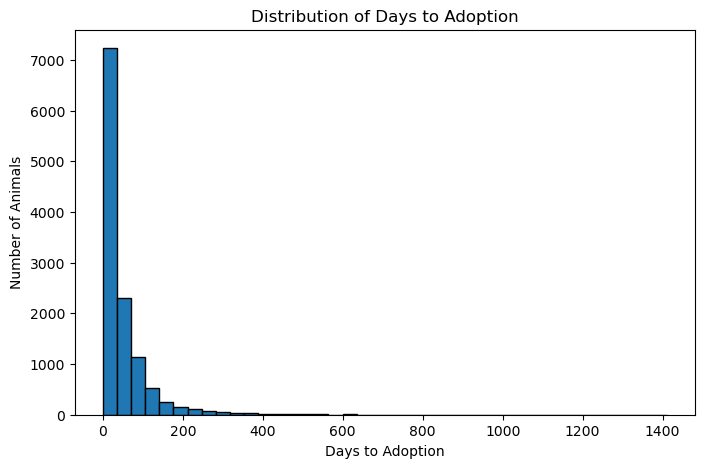

In [28]:
import matplotlib.pyplot as plt

X = reg_df.drop(columns=['days_to_adoption'])
y = reg_df['days_to_adoption'].copy()

print(X.shape)
print(y.shape)
print(y.describe())

plt.figure(figsize=(8, 5))
plt.hist(reg_df['days_to_adoption'], bins=40, edgecolor='black')
plt.xlabel('Days to Adoption')
plt.ylabel('Number of Animals')
plt.title('Distribution of Days to Adoption')
plt.show()

In [29]:
print(f"Median: {reg_df['days_to_adoption'].median():.0f} days")
print(f"75th percentile: {reg_df['days_to_adoption'].quantile(0.75):.0f} days")
print(f"90th percentile: {reg_df['days_to_adoption'].quantile(0.90):.0f} days")

Median: 25 days
75th percentile: 60 days
90th percentile: 112 days


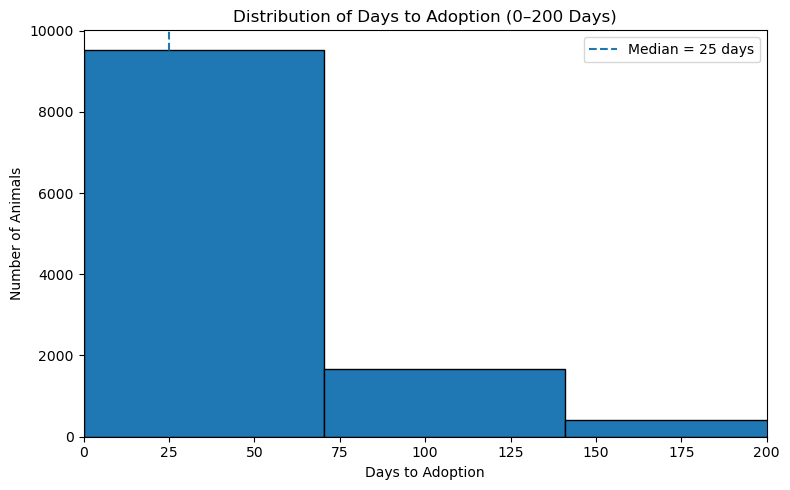

In [30]:
days = reg_df['days_to_adoption'].dropna()
median_val = days.median()

plt.figure(figsize=(8, 5))
plt.hist(days, bins=20, edgecolor='black')
plt.xlim(0, 200)
plt.axvline(median_val, linestyle='--', label=f'Median = {median_val:.0f} days')
plt.xlabel('Days to Adoption')
plt.ylabel('Number of Animals')
plt.title('Distribution of Days to Adoption (0–200 Days)')
plt.legend()
plt.tight_layout()
plt.show()

## 5.2 Group features for preprocessing ##
Different types of features need different preprocessing steps, so we group them before building the pipeline.

Categorical features will be one-hot encoded. The continuous variable `age_at_intake_days` will be scaled, while the cyclical features and binary indicators such as `has_name` and `intake_is_weekend` will be passed through directly.

In [31]:
categorical_cols = ['animal_type', 'primary_color', 'sex', 'intake_condition', 'intake_type']

scale_cols = ['age_at_intake_days']

passthrough_cols = [
    'intake_month_sin', 'intake_month_cos',
    'intake_dayofweek_sin', 'intake_dayofweek_cos',
    'has_name', 'intake_is_weekend'
]

print("Categorical:", categorical_cols)
print("Scaled:", scale_cols)
print("Passthrough:", passthrough_cols)

Categorical: ['animal_type', 'primary_color', 'sex', 'intake_condition', 'intake_type']
Scaled: ['age_at_intake_days']
Passthrough: ['intake_month_sin', 'intake_month_cos', 'intake_dayofweek_sin', 'intake_dayofweek_cos', 'has_name', 'intake_is_weekend']


## 5.3 Build the preprocessing pipeline ##
We build a preprocessing pipeline so that the same feature transformations are applied consistently across models. Categorical variables are one-hot encoded, `age_at_intake_days` is standardized after missing values are handled in the split data, and the cyclical and binary features are passed through without additional transformation.

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), scale_cols),
    ('pass', 'passthrough', passthrough_cols)
])

## 5.4 Create train/test split ##
We split the data into training and test sets. The training set is used for model selection and fitting, while the hold-out test set is reserved for the final evaluation so that we can better estimate how well the model generalizes to unseen data.


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train target mean (days): {y_train.mean():.2f}")
print(f"Test target mean (days): {y_test.mean():.2f}")

Training set: (9580, 12)
Test set: (2396, 12)
Train target mean (days): 49.09
Test target mean (days): 45.69


## 5.5 Fill NaNs with UNKNOWN as safety net

In [34]:
# Safety net applied directly to train/test sets
for col in categorical_cols:
    X_train[col] = X_train[col].fillna('UNKNOWN')
    X_test[col] = X_test[col].fillna('UNKNOWN')

print(X_train[categorical_cols].isnull().sum())
print(X_test[categorical_cols].isnull().sum())

animal_type         0
primary_color       0
sex                 0
intake_condition    0
intake_type         0
dtype: int64
animal_type         0
primary_color       0
sex                 0
intake_condition    0
intake_type         0
dtype: int64


## 5.6 Fill missing age values by animal type ##
After creating the train-test split, we fill missing values in `age_at_intake_days` using the median age within each animal type calculated from the training set. If an animal type does not have a valid median, we fall back to the overall training-set median.

In [35]:
overall_age_median = X_train['age_at_intake_days'].median()
age_median_by_type = X_train.groupby('animal_type')['age_at_intake_days'].median()

def fill_age_by_animal_type(df, age_map, fallback_median):
    df = df.copy()
    missing_mask = df['age_at_intake_days'].isnull()

    df.loc[missing_mask, 'age_at_intake_days'] = (
        df.loc[missing_mask, 'animal_type'].map(age_map)
    )

    df['age_at_intake_days'] = df['age_at_intake_days'].fillna(fallback_median)
    return df

X_train = fill_age_by_animal_type(X_train, age_median_by_type, overall_age_median)
X_test = fill_age_by_animal_type(X_test, age_median_by_type, overall_age_median)

print("Missing age in X_train:", X_train['age_at_intake_days'].isnull().sum())
print("Missing age in X_test:", X_test['age_at_intake_days'].isnull().sum())

Missing age in X_train: 0
Missing age in X_test: 0


In [36]:
reg_df.to_csv("../data/cleaned_data_regression.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# 6. Model training and evaluation ##

In this part, we train several candidate regression models and compare their performance. We first use cross-validation on the training set to identify the strongest candidates, and then use the hold-out test set for final comparison and model selection.

## 6.1 Model comparison with cross-validation ##

To compare models fairly, we evaluate each one using the same training data split and the same metrics: MAE, RMSE, and R2. MAE reflects the average prediction error, RMSE puts more weight on large errors, and R2 measures how much variation in the target is explained by the model.

We primarily selected models based on cross-validated MAE, since our goal was to minimize the average prediction error in days and MAE is easy to interpret in the original unit. It is also less sensitive to large errors than RMSE, which made it a practical metric for comparing models on this task. When models had very similar MAE values, we used cross-validated R2 and RMSE as additional reference metrics to compare overall fit and the effect of larger errors.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

model_specs = []

# Baselines
model_specs.append(("Dummy_mean", DummyRegressor(strategy='mean')))
model_specs.append(("Dummy_median", DummyRegressor(strategy='median')))

# Linear baseline
model_specs.append(("LinearRegression", LinearRegression()))

# Ridge
for alpha in [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]:
    model_specs.append((
        f"Ridge_alpha={alpha}",
        Ridge(alpha=alpha, random_state=42)
    ))

# Lasso
for alpha in [0.0001, 0.0005, 0.001, 0.005, 0.01]:
    model_specs.append((
        f"Lasso_alpha={alpha}",
        Lasso(alpha=alpha, max_iter=5000, random_state=42)
    ))

# ElasticNet
for alpha, l1_ratio in [
    (0.0005, 0.2),
    (0.0005, 0.5),
    (0.001, 0.2),
    (0.001, 0.5),
    (0.005, 0.5),
]:
    model_specs.append((
        f"ElasticNet_alpha={alpha}_l1={l1_ratio}",
        ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, random_state=42)
    ))

# Decision Tree
for depth, min_split, min_leaf in [
    (4, 20, 10),
    (6, 20, 10),
    (8, 10, 5),
    (10, 10, 5),
    (12, 5, 2),
    (16, 5, 1),
]:
    model_specs.append((
        f"DecisionTree_depth={depth}_minsplit={min_split}_minleaf={min_leaf}",
        DecisionTreeRegressor(
            max_depth=depth,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            random_state=42
        )
    ))

# Random Forest
for n_estimators, depth in [
    (40, 13),
    (50, 13),
    (60, 13),
    (70, 13),
    (40, 14),
    (50, 14),
    (60, 14),
    (70, 14),
    (40, 15),
    (50, 15),
    (60, 15),
    (70, 15),
]:
    label = f"RandomForest_n={n_estimators}_depth={depth}"

    model_specs.append((
        label,
        RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )
    ))

# Extra Trees
for n_estimators, depth, min_leaf in [
    (40, 12, 1),
    (50, 12, 1),
    (60, 12, 1),
    (40, 13, 1),
    (50, 13, 1),
    (60, 13, 1),
    (40, 14, 1),
    (50, 14, 1),
    (60, 14, 1),
    (50, 13, 2),
    (50, 14, 2),
]:
    model_specs.append((
        f"ExtraTrees_n={n_estimators}_depth={depth}_leaf={min_leaf}",
        ExtraTreesRegressor(
            n_estimators=n_estimators,
            max_depth=depth,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1
        )
    ))

# Gradient Boosting
for n_estimators, lr, depth, min_leaf in [
    (50, 0.1, 2, 5),
    (80, 0.1, 2, 5),
    (100, 0.05, 2, 5),
    (100, 0.1, 2, 5),
    (100, 0.05, 3, 5),
    (120, 0.05, 3, 3),
    (150, 0.05, 2, 5),
]:
    model_specs.append((
        f"GBR_n={n_estimators}_lr={lr}_depth={depth}_leaf={min_leaf}",
        GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=lr,
            max_depth=depth,
            min_samples_leaf=min_leaf,
            random_state=42
        )
    ))

# AdaBoost
for n_estimators, lr in [
    (50, 0.05),
    (100, 0.05),
    (150, 0.05),
    (50, 0.1),
    (100, 0.1),
    (150, 0.1),
]:
    model_specs.append((
        f"AdaBoost_n={n_estimators}_lr={lr}",
        AdaBoostRegressor(
            n_estimators=n_estimators,
            learning_rate=lr,
            random_state=42
        )
    ))

print(f"Total model configurations: {len(model_specs)}")

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_lookup = {params_label: model for params_label, model in model_specs}
results = []

for params_label, base_model in model_specs:
    wrapped_model = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', wrapped_model)
    ])

    # 1) Cross-validation
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        },
        n_jobs=-1
    )

    results.append({
        'model': base_model.__class__.__name__,
        'params': params_label,
        'CV_MAE': -cv_scores['test_mae'].mean(),
        'CV_RMSE': -cv_scores['test_rmse'].mean(),
        'CV_R2': cv_scores['test_r2'].mean(),
    })

results_df = (
    pd.DataFrame(results)
      .sort_values(by=['CV_MAE', 'CV_R2', 'CV_RMSE'],
                   ascending=[True, False, True])
      .reset_index(drop=True)
)

results_df.head(20)

Total model configurations: 61


,model,params,CV_MAE,CV_RMSE,CV_R2
0,RandomForestRegressor,RandomForest_n=70_depth=14,33.850825,75.350989,-0.006032
1,RandomForestRegressor,RandomForest_n=60_depth=14,33.851543,75.356131,-0.006185
2,RandomForestRegressor,RandomForest_n=60_depth=13,33.872653,75.441828,-0.008495
3,RandomForestRegressor,RandomForest_n=70_depth=13,33.878505,75.442284,-0.008512
4,RandomForestRegressor,RandomForest_n=50_depth=14,33.884540,75.383173,-0.006950
5,RandomForestRegressor,RandomForest_n=50_depth=13,33.888130,75.455646,-0.008879
6,RandomForestRegressor,RandomForest_n=70_depth=15,33.889459,75.274841,-0.004045
7,RandomForestRegressor,RandomForest_n=60_depth=15,33.890264,75.275594,-0.004046
8,RandomForestRegressor,RandomForest_n=50_depth=15,33.917889,75.294101,-0.004597
9,RandomForestRegressor,RandomForest_n=40_depth=14,33.919022,75.382337,-0.006950


## 6.2 Select the best model from cross-validation ##

In [55]:
best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_params = best_row['params']
best_base_model = model_lookup[best_params]

print("\nBest model selected from cross-validation:")
print(f"Model: {best_model_name}")
print(f"Params: {best_params}")
print(f"CV MAE: {best_row['CV_MAE']:.3f}")
print(f"CV RMSE: {best_row['CV_RMSE']:.3f}")
print(f"CV R2: {best_row['CV_R2']:.3f}")


Best model selected from cross-validation:
Model: RandomForestRegressor
Params: RandomForest_n=70_depth=14
CV MAE: 33.851
CV RMSE: 75.351
CV R2: -0.006


## 6.3 Final hold-out test evaluation ##
After selecting the best model from cross-validation, we evaluated it on the hold-out test set. This gives a final estimate of how well the selected model performs on unseen data.

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_lookup = {params_label: model for params_label, model in model_specs}
selected_base_model = model_lookup[best_params]

selected_wrapped_model = TransformedTargetRegressor(
    regressor=selected_base_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# fit preprocessor separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# fit regression model on processed features
selected_wrapped_model.fit(X_train_processed, y_train)
selected_test_preds = selected_wrapped_model.predict(X_test_processed)

selected_test_mae = mean_absolute_error(y_test, selected_test_preds)
selected_test_rmse = mean_squared_error(y_test, selected_test_preds) ** 0.5
selected_test_r2 = r2_score(y_test, selected_test_preds)

print("Final hold-out test performance of the selected model:")
print(f"Model: {best_model_name}")
print(f"Params: {best_params}")
print(f"Test MAE: {selected_test_mae:.3f}")
print(f"Test RMSE: {selected_test_rmse:.3f}")
print(f"Test R2: {selected_test_r2:.3f}")

Final hold-out test performance of the selected model:
Model: RandomForestRegressor
Params: RandomForest_n=70_depth=14
Test MAE: 30.528
Test RMSE: 59.055
Test R2: 0.055



## 6.4 Baseline comparison ##
To better interpret the regression results, we compare the selected model with simple baselines that do not use input features. This helps check whether the final model is actually learning useful predictive signal rather than only reflecting the overall distribution of adoption times.

### 6.4.1 Dummy baseline

We first use a `DummyRegressor` baseline under the same target transformation used in the modeling pipeline. This baseline ignores all features and predicts the same constant value for every sample, providing a simple reference point for model performance.

In [57]:
# Baseline comparison using DummyRegressor
# This baseline ignores all features and predicts a constant value under the same
# target transformation used in the main regression setup.

baseline_model = TransformedTargetRegressor(
    regressor=DummyRegressor(strategy="mean"),
    func=np.log1p,
    inverse_func=np.expm1
)

baseline_model.fit(X_train_processed, y_train)
baseline_preds = baseline_model.predict(X_test_processed)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print("Baseline (DummyRegressor) hold-out test performance:")
print(f"Baseline Test MAE: {baseline_mae:.3f}")
print(f"Baseline Test RMSE: {baseline_rmse:.3f}")
print(f"Baseline Test R2: {baseline_r2:.3f}")

print("\nImprovement over baseline (selected model - baseline):")
print(f"MAE improvement: {baseline_mae - selected_test_mae:.3f}")
print(f"RMSE improvement: {baseline_rmse - selected_test_rmse:.3f}")
print(f"R2 improvement: {selected_test_r2 - baseline_r2:.3f}")

Baseline (DummyRegressor) hold-out test performance:
Baseline Test MAE: 35.112
Baseline Test RMSE: 64.094
Baseline Test R2: -0.113

Improvement over baseline (selected model - baseline):
MAE improvement: 4.584
RMSE improvement: 5.039
R2 improvement: 0.168


### 6.4.2 Additional random baseline check
Since `days_to_adoption` is highly concentrated in the lower range, we also test several simple random baselines. These include multiple uniform random ranges and random sampling from the training target distribution. This helps check whether a model could appear reasonable by only guessing values from common parts of the target range.

In [58]:
np.random.seed(42)

# random baseline 1: uniform 0-10
rand_pred_10 = np.random.uniform(0, 10, size=len(y_test))

# random baseline 2: uniform 0-20
rand_pred_20 = np.random.uniform(0, 20, size=len(y_test))

# random baseline 3: uniform 0-50
rand_pred_50 = np.random.uniform(0, 50, size=len(y_test))

# random baseline 4: uniform 0-100
rand_pred_100 = np.random.uniform(0, 100, size=len(y_test))

# random baseline 5: sample from training target distribution
rand_pred_train = np.random.choice(y_train, size=len(y_test), replace=True)

random_baseline_results = []

def evaluate_preds(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    random_baseline_results.append({
        "baseline": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

evaluate_preds("Random baseline (0-10)", y_test, rand_pred_10)
evaluate_preds("Random baseline (0-20)", y_test, rand_pred_20)
evaluate_preds("Random baseline (0-50)", y_test, rand_pred_50)
evaluate_preds("Random baseline (0-100)", y_test, rand_pred_100)
evaluate_preds("Random baseline (sample from y_train)", y_test, rand_pred_train)

pd.DataFrame(random_baseline_results)

,baseline,MAE,RMSE,R2
0,Random baseline (0-10),41.274354,73.192355,-0.450993
1,Random baseline (0-20),38.774618,70.691931,-0.353548
2,Random baseline (0-50),37.734564,66.099143,-0.183384
3,Random baseline (0-100),45.844560,66.777967,-0.207815
4,Random baseline (sample from y_train),53.673205,90.674340,-1.226910


All of these random baselines produced negative R2 values and worse MAE and RMSE than the selected Random Forest model. This suggests that the final model is learning more than just the overall concentration of adoption times near the lower range.

## 6.5 Interpretation of results ##

The selected model outperformed the DummyRegressor baseline and random baselines on the hold-out test set, which indicates that intake-time features contain real predictive signal. At the same time, the absolute R2 value remains low, suggesting that the current feature set explains only a limited part of the variation in adoption time. In other words, the model is learning useful information, but adoption time is still difficult to predict precisely from intake-time data alone.

## 6.6 Predicted vs. actual values ##

To better understand the final model’s behavior, we compare predicted adoption days with the actual values on the hold-out test set. This helps show whether the model is capturing the general trend and where large prediction errors still remain.

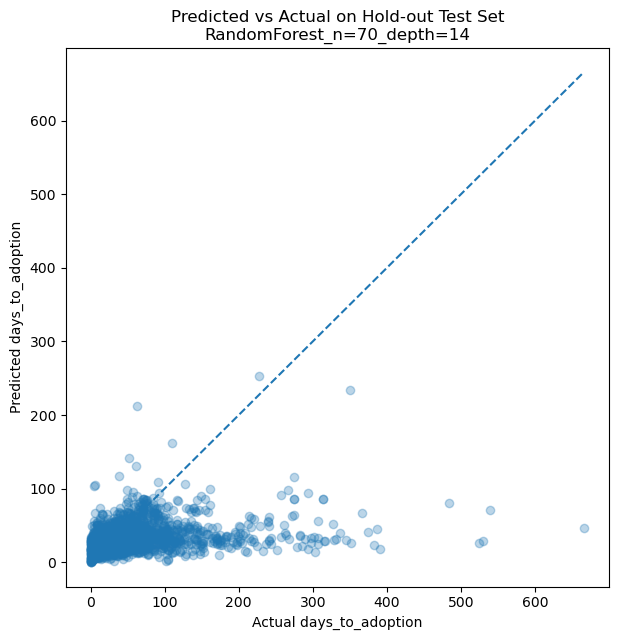

In [59]:
import matplotlib.pyplot as plt

y_pred = selected_wrapped_model.predict(X_test_processed)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
    [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
    linestyle='--'
)
plt.xlabel('Actual days_to_adoption')
plt.ylabel('Predicted days_to_adoption')
plt.title(f'Predicted vs Actual on Hold-out Test Set\n{best_params}')
plt.show()

This plot shows that the model is able to capture some overall pattern in the data, but the predictions are still quite spread out. Most predicted values stay in a relatively narrow range, while some actual adoption times are much larger. This suggests that the model does a better job on shorter adoption times and tends to underpredict animals that take much longer to be adopted.

#### Additional test-set breakdown by adoption-time threshold
Because `days_to_adoption` has a long right tail, we also looked at how the final model performed on subsets of the hold-out test set with shorter adoption windows. This was only used as a descriptive breakdown of the final model’s predictions, not as a separate model-selection step.

We evaluated the same hold-out predictions on cases with `days_to_adoption` less than or equal to 100, 200, 300, and 365 days. This helps show whether prediction difficulty mainly comes from a small number of extreme cases or from the broader long-tail portion of the target distribution.

In [60]:
thresholds = [100, 200, 300, 365]

subset_results = []

subset_results.append({
    'evaluation_set': 'Overall hold-out test',
    'threshold': 'All',
    'n_cases': len(y_test),
    'MAE': selected_test_mae,
    'RMSE': selected_test_rmse,
    'R2': selected_test_r2
})

for threshold in thresholds:
    subset_mask = y_test <= threshold
    y_true_subset = y_test[subset_mask]
    y_pred_subset = selected_test_preds[subset_mask]

    subset_results.append({
        'evaluation_set': f'Hold-out test (<= {threshold} days)',
        'threshold': threshold,
        'n_cases': subset_mask.sum(),
        'MAE': mean_absolute_error(y_true_subset, y_pred_subset),
        'RMSE': mean_squared_error(y_true_subset, y_pred_subset) ** 0.5,
        'R2': r2_score(y_true_subset, y_pred_subset) if len(y_true_subset) > 1 else np.nan
    })

subset_results_df = pd.DataFrame(subset_results)
display(subset_results_df)

,evaluation_set,threshold,n_cases,MAE,RMSE,R2
0,Overall hold-out test,All,2396,30.528147,59.055497,0.055386
1,Hold-out test (<= 100 days),100,2120,16.514286,22.463301,0.192273
2,Hold-out test (<= 200 days),200,2317,23.369782,36.821679,0.099015
3,Hold-out test (<= 300 days),300,2370,27.268428,47.294951,0.077170
4,Hold-out test (<= 365 days),365,2386,28.896762,52.212719,0.070146


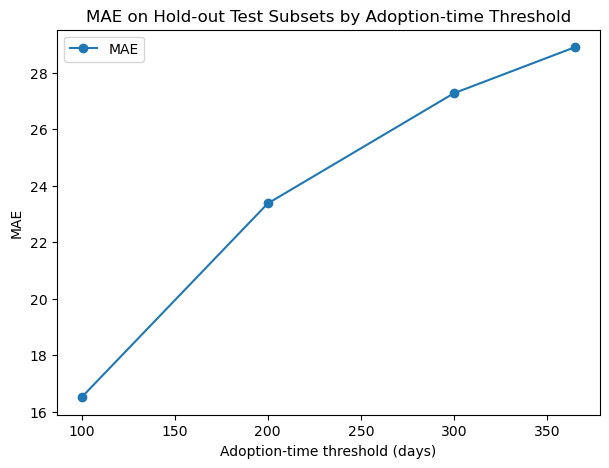

In [61]:
threshold_plot_df = subset_results_df[subset_results_df['threshold'] != 'All'].copy()

plt.figure(figsize=(7, 5))
plt.plot(threshold_plot_df['threshold'], threshold_plot_df['MAE'], marker='o', label='MAE')
plt.xlabel('Adoption-time threshold (days)')
plt.ylabel('MAE')
plt.title('MAE on Hold-out Test Subsets by Adoption-time Threshold')
plt.legend()
plt.show()

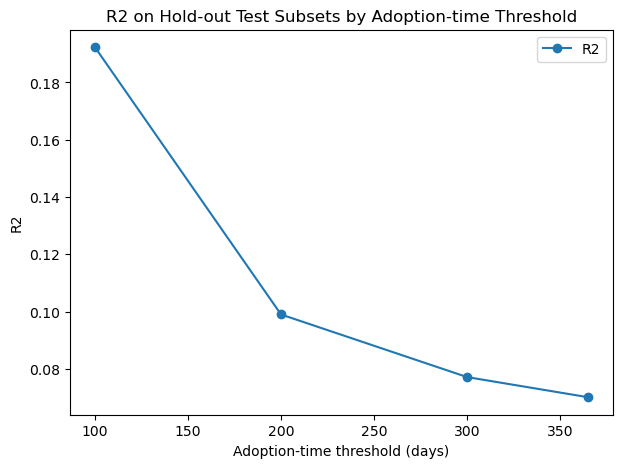

In [62]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_plot_df['threshold'], threshold_plot_df['R2'], marker='o', label='R2')
plt.xlabel('Adoption-time threshold (days)')
plt.ylabel('R2')
plt.title('R2 on Hold-out Test Subsets by Adoption-time Threshold')
plt.legend()
plt.show()

The subset results show that the model performs better when evaluation is restricted to shorter adoption windows. Performance improves gradually as the threshold becomes smaller, especially for MAE and RMSE. This suggests that prediction difficulty is not caused only by a few extreme outliers, but more broadly by the longer-tail portion of the target distribution. In other words, the model appears to work better for shorter and more common adoption windows than for longer adoption times.

#### Additional test-set breakdown by animal type
To further examine whether the overall regression difficulty varies across animal groups, we also evaluated the final model separately on cats, dogs, and guinea pigs. This analysis was not used for model selection; it was only used to better understand subgroup performance and possible sources of heterogeneity in the target.

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# make sure y_test is a Series aligned with X_test
y_test_series = pd.Series(y_test, index=X_test.index)
pred_test_series = pd.Series(selected_test_preds, index=X_test.index)

animal_groups = ['CAT', 'DOG', 'GUINEA PIG']

animal_results = []

for animal in animal_groups:
    mask = X_test['animal_type'] == animal
    
    X_sub = X_test.loc[mask]
    y_sub = y_test_series.loc[mask]
    pred_sub = pred_test_series.loc[mask]
    
    if len(X_sub) == 0:
        continue
    
    animal_results.append({
        'animal_type': animal,
        'n_cases': len(X_sub),
        'MAE': mean_absolute_error(y_sub, pred_sub),
        'RMSE': mean_squared_error(y_sub, pred_sub) ** 0.5,
        'R2': r2_score(y_sub, pred_sub) if len(y_sub) > 1 else np.nan
    })

animal_results_df = pd.DataFrame(animal_results)
display(animal_results_df)

,animal_type,n_cases,MAE,RMSE,R2
0,CAT,1326,32.104460,60.306900,0.068998
1,DOG,975,28.866171,58.040284,-0.025845
2,GUINEA PIG,15,58.293558,105.685854,0.059692


## 6.7 Feature importance ##

Since the selected model is a Random Forest regressor, we can also inspect feature importance scores to see which inputs contribute most to the prediction. This gives a simple way to interpret what kinds of intake-time information the model relies on most.

In [64]:
# Get transformed feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# Access the fitted Random Forest inside TransformedTargetRegressor
rf_model = selected_wrapped_model.regressor_

# Build feature importance table
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 feature importances:")
print(importance_df.head(20))

Top 20 feature importances:
                                feature  importance
38              num__age_at_intake_days    0.325454
39               pass__intake_month_sin    0.078251
40               pass__intake_month_cos    0.070197
41           pass__intake_dayofweek_sin    0.061244
42           pass__intake_dayofweek_cos    0.040249
34              cat__intake_type_RETURN    0.026631
43                       pass__has_name    0.025593
28         cat__intake_condition_NORMAL    0.025280
2                  cat__animal_type_DOG    0.022621
17        cat__primary_color_WHITE/PINK    0.019704
7              cat__primary_color_BLACK    0.019676
19                        cat__sex_MALE    0.019020
20                    cat__sex_NEUTERED    0.016805
1                  cat__animal_type_CAT    0.016539
18                      cat__sex_FEMALE    0.015929
33     cat__intake_type_OWNER SURRENDER    0.015704
21                      cat__sex_SPAYED    0.014267
15             cat__primary_color_TA

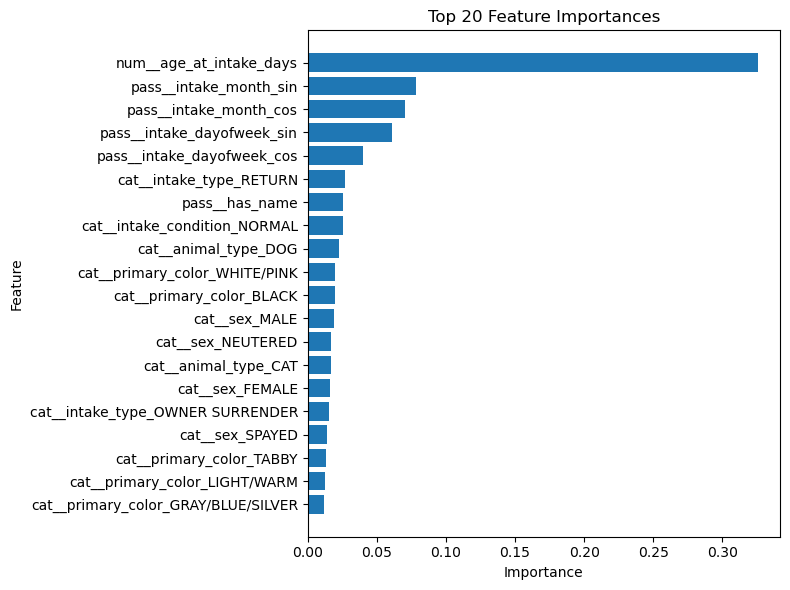

In [65]:
top_n = 20
top_features = importance_df.head(top_n).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

This plot shows that `age_at_intake_days` is the most important feature in the final model. The intake month and intake day-of-week features also appear near the top, which suggests that timing information matters for adoption time. Other categorical features, such as sex, intake condition, intake type, and primary color, still contribute to the model, but each individual category has a smaller effect after one-hot encoding.

# 7. Export the model

In [66]:
import joblib

# use the final selected model setting from hold-out evaluation
final_base_model = model_lookup[best_params]

final_wrapped_model = TransformedTargetRegressor(
    regressor=final_base_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# fill age on the full dataset using animal-type median
overall_age_median_full = X['age_at_intake_days'].median()
age_median_by_type_full = X.groupby('animal_type')['age_at_intake_days'].median()
X_full = fill_age_by_animal_type(X, age_median_by_type_full, overall_age_median_full)

# fit preprocessor on the full cleaned dataset
X_full_processed = preprocessor.fit_transform(X_full)

# fit regression model on processed features
final_wrapped_model.fit(X_full_processed, y)

# save separately
joblib.dump(preprocessor, "../data/regression_preprocessor.joblib", compress=3)
joblib.dump(final_wrapped_model, "../data/regression_best_model.joblib", compress=3)
joblib.dump(X_full.columns.tolist(), "../data/regression_feature_columns.joblib")

print("Saved regression_preprocessor.joblib")
print("Saved regression_best_model.joblib")
print("Saved regression_feature_columns.joblib")

Saved regression_preprocessor.joblib
Saved regression_best_model.joblib
Saved regression_feature_columns.joblib
